# Local-Global Oddball Dataset — Data Loading
**Allen Institute Openscope, DANDI 000253**  
Westerberg et al. (2024) · doi:10.48324/dandi.000253/0.240923.1441

## File organisation (per subject)
```
sub-XXXXXX/
├── sub-*_ses-*_ogen.nwb          ← session file: units, stimulus, behavior, optotagging
├── sub-*_ses-*_probe-0_ecephys.nwb  ← LFP only, probe 0
│   ...
└── sub-*_ses-*_probe-5_ecephys.nwb  ← LFP only, probe 5
```
All spike analysis uses the `_ogen.nwb` file.  
LFP is loaded separately from the relevant `_probe-N_ecephys.nwb` file.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pynwb

DATA_ROOT = Path("/home/kati/Data/000253")

# All subject directories, sorted
subjects = sorted(DATA_ROOT.glob("sub-*"))
print(f"{len(subjects)} subjects found:")
for s in subjects:
    files = list(s.glob("*.nwb"))
    print(f"  {s.name}  ({len(files)} NWB files)")

14 subjects found:
  sub-621890  (7 NWB files)
  sub-632485  (7 NWB files)
  sub-632487  (7 NWB files)
  sub-637542  (7 NWB files)
  sub-637908  (7 NWB files)
  sub-637909  (7 NWB files)
  sub-640507  (7 NWB files)
  sub-642507  (7 NWB files)
  sub-645322  (7 NWB files)
  sub-645324  (7 NWB files)
  sub-645495  (7 NWB files)
  sub-647836  (7 NWB files)
  sub-649323  (7 NWB files)
  sub-649324  (7 NWB files)


In [2]:
def get_session_paths(subject_dir: Path) -> dict:
    """Return a dict with 'session' and 'probes' (list of 6 paths) for a subject dir."""
    ogen = list(subject_dir.glob("*_ogen.nwb"))
    probes = sorted(subject_dir.glob("*_probe-*_ecephys.nwb"))
    assert len(ogen) == 1, f"Expected 1 ogen file, found {len(ogen)}"
    return {"session": ogen[0], "probes": probes}

# Pick one subject for exploration
subject_dir = DATA_ROOT / "sub-621890"
paths = get_session_paths(subject_dir)
print("Session file:", paths["session"].name)
print("Probe files:")
for p in paths["probes"]:
    print(" ", p.name)

Session file: sub-621890_ses-1186358749_ogen.nwb
Probe files:
  sub-621890_ses-1186358749_probe-0_ecephys.nwb
  sub-621890_ses-1186358749_probe-1_ecephys.nwb
  sub-621890_ses-1186358749_probe-2_ecephys.nwb
  sub-621890_ses-1186358749_probe-3_ecephys.nwb
  sub-621890_ses-1186358749_probe-4_ecephys.nwb
  sub-621890_ses-1186358749_probe-5_ecephys.nwb


## 1. Session file (`_ogen.nwb`)
Contains: sorted units (all probes), stimulus intervals, running speed, eye tracking, optotagging.

In [3]:
session_io = pynwb.NWBHDF5IO(paths["session"], mode="r", load_namespaces=True)
session = session_io.read()

print(f"Session ID : {session.session_id}")
print(f"Subject    : {session.subject.subject_id}  genotype={session.subject.genotype}")
print(f"Start time : {session.session_start_time}")

Session ID : 1186358749
Subject    : 621890  genotype=Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
Start time : 2022-06-22 00:00:00-07:00


### 1a. Units

In [4]:
units = session.units.to_dataframe()
print(f"Total units : {len(units)}")
print(f"Quality     : {units.quality.value_counts().to_dict()}")
print(f"Columns     : {list(units.columns)}\n")

# Good units only
good_units = units[units.quality == "good"].copy()
print(f"Good units  : {len(good_units)}")
good_units[["firing_rate", "snr", "isi_violations", "presence_ratio", "peak_channel_id"]].describe()

Total units : 2446
Quality     : {'good': 2051, 'noise': 395}
Columns     : ['cumulative_drift', 'local_index', 'firing_rate', 'l_ratio', 'silhouette_score', 'spread', 'cluster_id', 'velocity_above', 'recovery_slope', 'nn_miss_rate', 'nn_hit_rate', 'waveform_halfwidth', 'quality', 'peak_channel_id', 'isi_violations', 'amplitude_cutoff', 'd_prime', 'repolarization_slope', 'PT_ratio', 'snr', 'isolation_distance', 'amplitude', 'max_drift', 'waveform_duration', 'presence_ratio', 'velocity_below', 'spike_times', 'spike_amplitudes', 'waveform_mean']

Good units  : 2051


,firing_rate,snr,isi_violations,presence_ratio,peak_channel_id
count,2051.000000,2051.000000,2051.000000,2051.000000,2051.000000
mean,6.137996,2.663722,3.662404,0.912974,2571.314481
std,8.971552,1.158315,74.963667,0.181543,1770.173415
min,0.000907,0.163096,0.000000,0.020000,2.000000
25%,0.698841,1.901679,0.005149,0.970000,1104.500000
50%,2.971976,2.452312,0.066534,0.990000,2218.000000
75%,7.591403,3.189421,0.370368,0.990000,4198.000000
max,86.472290,7.849980,3253.970577,0.990000,5281.000000


In [5]:
# Spike times are stored as a ragged array — index into session.units directly
# (the to_dataframe() spike_times column holds numpy arrays)
unit_idx = good_units.index[0]
spike_times = session.units["spike_times"][unit_idx]

print(f"Unit {unit_idx}: {len(spike_times)} spikes")
print(f"  t = [{spike_times[0]:.2f}, {spike_times[-1]:.2f}] s")
print(f"  firing rate = {good_units.loc[unit_idx, 'firing_rate']:.2f} Hz")

Unit 18: 73813 spikes
  t = [7.20, 7721.89] s
  firing rate = 7.84 Hz


### 1b. Stimulus intervals
The Local-Global paradigm is in `init_grating_presentations`.  
Each row is one 500 ms grating stimulus; `stimulus_block` groups presentations into sequences.

In [6]:
stim_tables = {name: iv.to_dataframe() for name, iv in session.intervals.items()}

print("Stimulus tables:")
for name, df in stim_tables.items():
    print(f"  {name}: {len(df)} rows")

# Main paradigm table
gratings = stim_tables["init_grating_presentations"]
keep_cols = ["start_time", "stop_time", "stimulus_block", "orientation",
             "spatial_frequency", "temporal_frequency", "contrast"]
gratings[keep_cols].head(8)

Stimulus tables:
  create_receptive_field_mapping_presentations: 1944 rows
  init_grating_presentations: 6035 rows
  init_intermission_presentations: 50 rows
  invalid_times: 1 rows
  spontaneous_presentations: 51 rows


,start_time,stop_time,stimulus_block,orientation,spatial_frequency,temporal_frequency,contrast
id,,,,,,,
0,40.09937,40.59978,1.0,135.0,0.04,4.0,0.8
1,41.10021,41.60062,1.0,135.0,0.04,4.0,0.8
2,42.10105,42.60146,1.0,135.0,0.04,4.0,0.8
3,43.10188,43.60227,1.0,45.0,0.04,4.0,0.8
4,44.10273,44.60314,1.0,NaN,NaN,NaN,NaN
5,45.10358,45.60399,1.0,135.0,0.04,4.0,0.8
6,46.10442,46.60483,1.0,135.0,0.04,4.0,0.8
7,47.10528,47.60566,1.0,135.0,0.04,4.0,0.8


In [7]:
# Block structure: each block is a sequence of same-orientation gratings
block_summary = (
    gratings.groupby("stimulus_block")
    .agg(
        n_stim=("start_time", "count"),
        orientation=("orientation", lambda x: x.dropna().unique().tolist()),
        t_start=("start_time", "min"),
        t_stop=("stop_time", "max"),
    )
    .head(10)
)
block_summary

,n_stim,orientation,t_start,t_stop
stimulus_block,,,,
1.0,125,"[135.0, 45.0]",40.09937,164.70409
3.0,125,"[135.0, 45.0]",175.21293,299.81764
5.0,125,"[135.0, 45.0]",310.32647,434.93118
7.0,125,"[135.0, 45.0]",445.43998,570.04472
9.0,125,"[135.0, 45.0]",580.55356,705.15829
11.0,125,"[135.0, 45.0]",715.66710,840.27181
13.0,125,"[135.0, 45.0]",850.78065,975.38536
15.0,125,"[135.0, 45.0]",985.89418,1110.49891
17.0,125,"[135.0, 45.0]",1121.00777,1245.61249


### 1c. Behavior

In [8]:
running = session.processing["running"]
run_speed = running["running_speed"]
# running_speed has no .rate — reconstruct time from end-time companion series
run_speed_end = running["running_speed_end_times"]

run_t = run_speed_end.data[()]        # end-time of each sample window
run_v = run_speed.data[()]            # cm/s

print(f"Running speed: {len(run_v)} samples, t=[{run_t[0]:.2f}, {run_t[-1]:.2f}] s")
print(f"  range: [{run_v.min():.1f}, {run_v.max():.1f}] cm/s")
print(f"  median: {np.median(run_v):.1f} cm/s")

Running speed: 400823 samples, t=[nan, nan] s
  range: [-746.7, 120.6] cm/s
  median: 41.0 cm/s


In [9]:
eye = session.acquisition["EyeTracking"]
pupil_xy  = eye.spatial_series["pupil_tracking"].data[()]          # (N, 2) pixels
pupil_t   = eye.spatial_series["pupil_tracking"].timestamps[()]    # seconds
eye_xy    = eye.spatial_series["eye_tracking"].data[()]
cr_xy     = eye.spatial_series["corneal_reflection_tracking"].data[()]

print(f"Eye tracking: {len(pupil_t)} frames, t=[{pupil_t[0]:.2f}, {pupil_t[-1]:.2f}] s")
print(f"  pupil_xy shape : {pupil_xy.shape}")
print(f"  eye_xy shape   : {eye_xy.shape}")
print(f"  cr_xy shape    : {cr_xy.shape}")

Eye tracking: 463365 frames, t=[2.13, nan] s
  pupil_xy shape : (463365, 2)
  eye_xy shape   : (463365, 2)
  cr_xy shape    : (463365, 2)


### 1d. Optotagging

In [10]:
opto = session.processing["optotagging"]["optogenetic_stimulation"].to_dataframe()
keep = ["start_time", "stop_time", "stimulus_name", "condition", "level", "duration"]
print(f"Optotagging trials: {len(opto)}")
print(f"Conditions: {opto.stimulus_name.unique().tolist()}")
opto[keep].head(6)

Optotagging trials: 450
Conditions: ['5 hz pulse train', '40 hz pulse train', 'raised_cosine']


,start_time,stop_time,stimulus_name,condition,level,duration
id,,,,,,
0,6781.99807,6782.99807,5 hz pulse train,Each pulse is 10 ms wide,0.77,1.0
1,6783.95800,6784.95800,40 hz pulse train,Each pulse is 6 ms wide,0.77,1.0
2,6785.72773,6786.72773,5 hz pulse train,Each pulse is 10 ms wide,0.97,1.0
3,6787.64760,6788.64760,40 hz pulse train,Each pulse is 6 ms wide,0.77,1.0
4,6789.73925,6790.73925,raised_cosine,half-period of a cosine wave,1.35,1.0
5,6791.90070,6792.90070,40 hz pulse train,Each pulse is 6 ms wide,0.97,1.0


## 2. LFP files (`_probe-N_ecephys.nwb`)
Each probe file contains one `ElectricalSeries` with shape `(n_timepoints, n_channels)`.  
Channels carry brain-area labels and probe coordinates.

In [11]:
# Open probe-2 as example (~5.6 GB, one of the smaller ones)
probe_io = pynwb.NWBHDF5IO(paths["probes"][2], mode="r", load_namespaces=True)
probe_nwb = probe_io.read()

# The LFP object wraps the ElectricalSeries
lfp_obj = probe_nwb.acquisition["probe_2_lfp"]
lfp_es  = lfp_obj.electrical_series["probe_2_lfp_data"]

print(f"Probe: {list(probe_nwb.electrode_groups.keys())}")
print(f"LFP shape : {lfp_es.data.shape}   (timepoints × channels)")
print(f"Unit      : {lfp_es.unit}")

electrodes = probe_nwb.electrodes.to_dataframe()
print(f"\nChannels  : {len(electrodes)}")
print(f"Brain areas: {electrodes.location.unique().tolist()}")
electrodes[["location", "probe_vertical_position", "probe_horizontal_position",
            "x", "y", "z", "valid_data"]].head(8)

Probe: ['probeC']
LFP shape : (9646380, 276)   (timepoints × channels)
Unit      : volts



Channels  : 276
Brain areas: ['SCig', 'POST', 'VISp6b', 'VISp6a', 'VISp5', 'VISp4', 'VISp2/3', 'VISp1', 'root']


,location,probe_vertical_position,probe_horizontal_position,x,y,z,valid_data
id,,,,,,,
2000,SCig,20,43,8941.0,2318.0,7528.0,True
2001,SCig,20,11,8944.0,2311.0,7531.0,True
2002,POST,40,59,8947.0,2304.0,7534.0,True
2003,POST,40,27,8950.0,2297.0,7537.0,True
2004,POST,60,43,8953.0,2290.0,7539.0,True
2005,POST,60,11,8953.0,2290.0,7539.0,True
2006,POST,80,59,8956.0,2283.0,7542.0,True
2007,POST,80,27,8959.0,2275.0,7545.0,True


In [12]:
# LFP timestamps (irregular — stored as a timestamps array, not a fixed rate)
lfp_t = lfp_es.timestamps[()]
lfp_fs = 1.0 / np.median(np.diff(lfp_t[:10_000]))   # estimate sample rate

print(f"LFP timestamps: {len(lfp_t)} samples")
print(f"  t = [{lfp_t[0]:.4f}, {lfp_t[-1]:.4f}] s")
print(f"  estimated Fs ≈ {lfp_fs:.1f} Hz")

LFP timestamps: 9646380 samples
  t = [4.8325, 7721.8990] s
  estimated Fs ≈ 1250.0 Hz


In [13]:
# Slice a short LFP window (lazy — only reads the requested rows from disk)
def get_lfp_window(lfp_es, lfp_t, t_start, t_stop):
    """Return (snippet_array, time_array) for [t_start, t_stop] seconds."""
    idx = np.searchsorted(lfp_t, [t_start, t_stop])
    data = lfp_es.data[idx[0]:idx[1], :]   # (n_samples, n_channels)
    t    = lfp_t[idx[0]:idx[1]]
    return data, t

# Example: first 2 seconds of recording
lfp_snippet, t_snippet = get_lfp_window(lfp_es, lfp_t, lfp_t[0], lfp_t[0] + 2.0)
print(f"Snippet shape: {lfp_snippet.shape}  ({lfp_snippet.shape[0]} samples × {lfp_snippet.shape[1]} channels)")
print(f"Value range  : [{lfp_snippet.min()*1e6:.1f}, {lfp_snippet.max()*1e6:.1f}] µV")

Snippet shape: (2501, 276)  (2501 samples × 276 channels)
Value range  : [-1072.7, 805.4] µV


## 3. Quick sanity plots

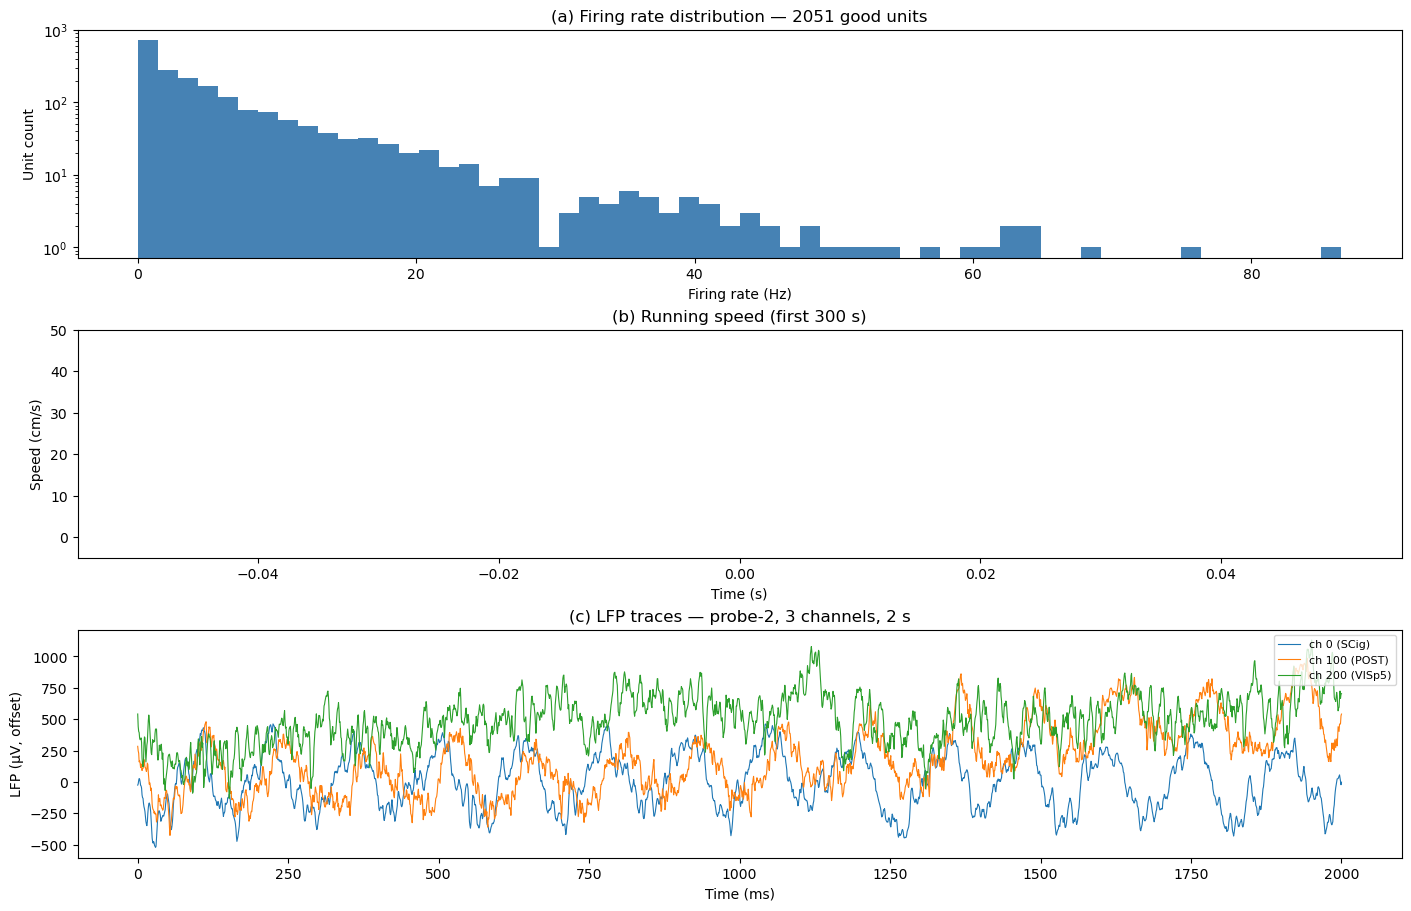

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(14, 9), constrained_layout=True)

# --- (a) Firing rate distribution ---
ax = axes[0]
ax.hist(good_units.firing_rate, bins=60, color="steelblue", edgecolor="none")
ax.set_xlabel("Firing rate (Hz)")
ax.set_ylabel("Unit count")
ax.set_title(f"(a) Firing rate distribution — {len(good_units)} good units")
ax.set_yscale("log")

# --- (b) Running speed (first 300 s) ---
ax = axes[1]
mask = run_t < 300
ax.plot(run_t[mask], run_v[mask], lw=0.6, color="darkorange")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (cm/s)")
ax.set_title("(b) Running speed (first 300 s)")
ax.set_ylim(-5, 50)

# --- (c) LFP trace — 3 channels, 2 s ---
ax = axes[2]
ch_idx = [0, 100, 200]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
t_rel = (t_snippet - t_snippet[0]) * 1000   # ms
offset = 300e-6   # 300 µV offset between traces
for i, (ch, col) in enumerate(zip(ch_idx, colors)):
    area = electrodes.iloc[ch]["location"]
    ax.plot(t_rel, lfp_snippet[:, ch] * 1e6 + i * 300,
            lw=0.8, color=col, label=f"ch {ch} ({area})")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("LFP (µV, offset)")
ax.set_title("(c) LFP traces — probe-2, 3 channels, 2 s")
ax.legend(loc="upper right", fontsize=8)

plt.savefig("sanity_check.png", dpi=120)
plt.show()

## 4. Cleanup
Close file handles when done to release HDF5 locks.

In [15]:
session_io.close()
probe_io.close()